This section builds visualizations based off the data set collected in the sat_data section

In [375]:
import pandas as pd
import matplotlib.pyplot as plt
import leafmap as leafmap
#import numpy as np

In [376]:
# leafmap code generated by Copilot AI
file = 'buoy_locations.txt'
df = pd.read_csv(file, header = None)

df.columns = ['Buoy', 'Latitude', 'Longitude']

m = leafmap.Map(
    height=1000,
    width=1200,
    center=(0, 0),
    zoom=2,
)

m.add_circle_markers_from_xy(df, x='Longitude', y='Latitude')
m

Map(center=[0, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text'…

In [377]:
df_chl = pd.read_csv('buoy_chl_attached.csv')
df_chl.columns = ['buoy', 'date', 'lat', 'lon', 'chlor_a']

In [378]:
# dictionary for loop to create a dictionary of buoys with their chlorophyll values for each date
# 
buoy_chl = {}
for index, row in df_chl.iterrows():
    buoy = row['buoy']
    date = row['date']
    #location = ([row['lat'], row['lon']])
    if buoy not in buoy_chl.keys():
        buoy_chl.update({buoy: []})
    if row['chlor_a'] >= 0:
        buoy_chl[buoy].append((date))

In [379]:
# creating a list of lists for each buoys pCO2 collection dates
dates = []
for key in buoy_chl.keys():
    dates.append(buoy_chl[key])

Text(0.5, 1.0, 'Collection dates of pCO2 data for each buoy')

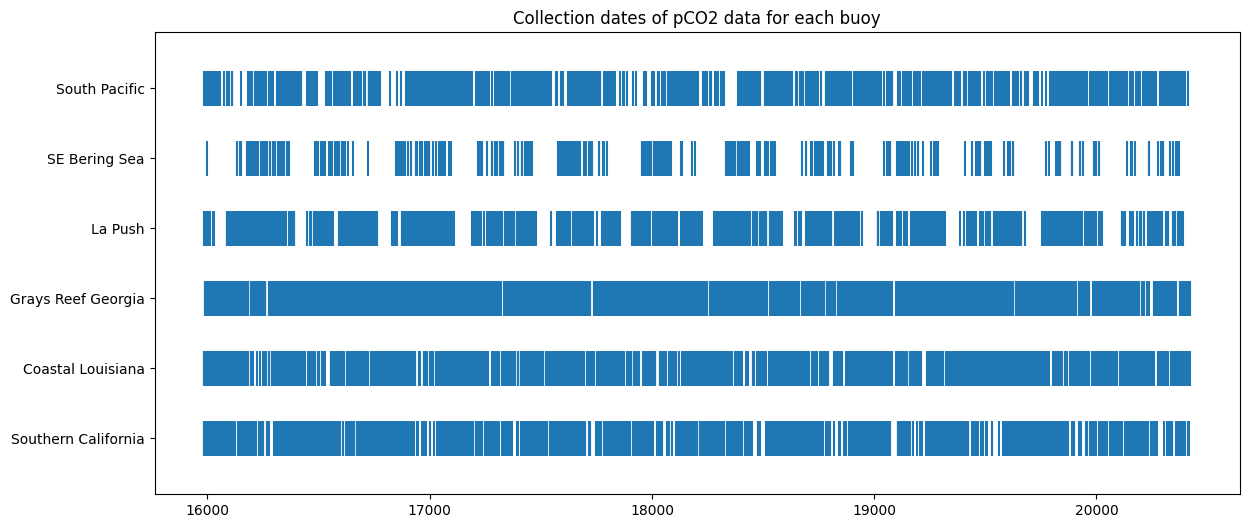

In [380]:
# creating an eventplot to show gaps in buoy data; Edited by Copilot to correctly plot dates
import matplotlib.dates as mdates
plt.figure(figsize=(14, 6))
offsets = [2,4,6,8,10,12]
plot_dates = [mdates.date2num(pd.to_datetime(group)) for group in dates]
plt.eventplot(plot_dates, lineoffsets = offsets)
names = buoy_chl.keys()
plt.yticks(offsets, names)
plt.title('Collection dates of pCO2 data for each buoy')

Citation for Copilot code:
Microsoft. (2026). Conversation with AI assistant about data visualization techniques in Python [Generative AI chat]. Copilot. https://copilot.microsoft.com